In [99]:
import os
from contextlib import redirect_stdout
from datetime import datetime, timezone
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import xarray as xr
from IPython.display import HTML, display
from ipywidgets import widgets
from matplotlib.figure import Figure
from numpy.typing import NDArray

import ttide as tt

HTML("""
    <style>
    .cell-output-ipywidget-background{background: transparent !important;}
    .widget-label{color: white !important;}
    </style>
""")

In [2]:
NOTEBOOK_DIR = Path().resolve()
DATA_DIR = NOTEBOOK_DIR / "../data"
FIGURES_DIR = NOTEBOOK_DIR / "../figures"
VEL_PATH_V1 = (
    DATA_DIR
    / "NH10_Mooring_Data/nh10_hourly_data_1997_2021_rotated_filtered_streamwise.nc"
)
VEL_PATH_V5 = (
    DATA_DIR
    / "NH10_Mooring_Data/nh10_hourly_data_1997_2021_rotated_filtered_streamwise_v5.nc"
)

GLOBEC_TIME = slice(np.datetime64("1997-01-01"), np.datetime64("2004-12-31"))
NANOOS_TIME = slice(np.datetime64("2006-07-01"), np.datetime64("2014-09-30"))
OOI_TIME = slice(np.datetime64("2015-04-01"), None)

In [3]:
def fit_ttide(u: xr.DataArray, v: xr.DataArray) -> dict:
    """Fit a T-Tide model to the given u and v components."""
    # u and v should have the same time dimension
    seconds_since_epoch = (u.time[0].values - np.datetime64(0, "s")) / np.timedelta64(
        1, "s"
    )
    stime = datetime.fromtimestamp(seconds_since_epoch, tz=timezone.utc)

    # don't need to print the output of t_tide, so redirect stdout to devnull
    with open(os.devnull, "w") as devnull:
        with redirect_stdout(devnull):
            # just save the dict output of t_tide
            out = tt.t_tide(
                u[:].values + v[:].values * 1j,
                lat=44.64,
                dt=1,
                stime=stime,
            )

    # squeeze the output arrays to remove any singleton dimensions
    out = {k: v.squeeze() for k, v in out.items() if isinstance(v, np.ndarray)}

    # out is a dict with keys 'nobs', 'ngood', 'dt', 'xin', 'xout', 'xres', 'xingd', 'xoutgd', 'xresgd', 'isComplex', 'ray', 'nodcor', 'z0', 'dz0', 'fu', 'nameu', 'tidecon', 'snr', 'synth', 'lat', 'ltype', 'stime'
    return out

In [4]:
velocity_v1 = xr.open_dataset(VEL_PATH_V1).resample(time="1h").mean()
velocity_v5 = xr.open_dataset(VEL_PATH_V5).resample(time="1h").mean()

velocity_v1_nanoos = velocity_v1.sel(time=NANOOS_TIME)
velocity_v5_nanoos = velocity_v5.sel(time=NANOOS_TIME)
velocity_v1_ooi = velocity_v1.sel(time=OOI_TIME)
velocity_v5_ooi = velocity_v5.sel(time=OOI_TIME)

In [32]:
ds_list = []
for depth in velocity_v1_nanoos["depth"]:
    out = fit_ttide(
        velocity_v1_nanoos["u"].sel(depth=depth),
        velocity_v1_nanoos["v"].sel(depth=depth),
    )
    out["nameu"] = [name.astype(str).strip() for name in out["nameu"]]
    out_ds = xr.Dataset(
        {
            "uin": (["time"], out["xin"].real),
            "vin": (["time"], out["xin"].imag),
            "uout": (["time"], out["xout"].real),
            "vout": (["time"], out["xout"].imag),
            "ures": (["time"], out["xres"].real),
            "vres": (["time"], out["xres"].imag),
            "fu": (["constituent"], out["fu"]),
            "snr": (["constituent"], out["snr"]),
            "major": (["constituent"], out["tidecon"][:, 0]),
            "emajor": (["constituent"], out["tidecon"][:, 1]),
            "minor": (["constituent"], out["tidecon"][:, 2]),
            "eminor": (["constituent"], out["tidecon"][:, 3]),
            "inc": (["constituent"], out["tidecon"][:, 4]),
            "einc": (["constituent"], out["tidecon"][:, 5]),
            "phase": (["constituent"], out["tidecon"][:, 6]),
            "ephase": (["constituent"], out["tidecon"][:, 7]),
        },
        coords={
            "time": velocity_v1_nanoos.time,
            "constituent": out["nameu"],
        },
    )
    out_ds = out_ds.expand_dims({"depth": [depth.values]}, axis=0)
    ds_list.append(out_ds)

tide_out = xr.concat(ds_list, dim="depth")

In [90]:
def plot_tidal_constituents(
    tide_ds: xr.Dataset, constituent: str, fig: Figure | None = None
) -> tuple[Figure, NDArray]:
    """Plot the tidal constituents from a T-Tide output dataset."""
    if fig is None:
        fig, axs = plt.subplots(1, 5, figsize=(12, 6))
    else:
        axs = fig.get_axes()
    axs[0].plot(tide_ds["major"], -tide_ds["depth"], label=constituent)
    axs[0].fill_betweenx(
        -tide_ds["depth"],
        tide_ds["major"] - tide_ds["emajor"],
        tide_ds["major"] + tide_ds["emajor"],
        alpha=0.3,
    )
    axs[1].plot(tide_ds["minor"], -tide_ds["depth"], label=constituent)
    axs[1].fill_betweenx(
        -tide_ds["depth"],
        tide_ds["minor"] - tide_ds["eminor"],
        tide_ds["minor"] + tide_ds["eminor"],
        alpha=0.3,
    )
    axs[2].plot(tide_ds["inc"], -tide_ds["depth"], label=constituent)
    axs[2].fill_betweenx(
        -tide_ds["depth"],
        tide_ds["inc"] - tide_ds["einc"],
        tide_ds["inc"] + tide_ds["einc"],
        alpha=0.3,
    )
    axs[3].plot(tide_ds["phase"], -tide_ds["depth"], label=constituent)
    axs[3].fill_betweenx(
        -tide_ds["depth"],
        tide_ds["phase"] - tide_ds["ephase"],
        tide_ds["phase"] + tide_ds["ephase"],
        alpha=0.3,
    )
    axs[4].plot(tide_ds["snr"], -tide_ds["depth"], label=constituent)
    axs[4].set_xscale("log")
    axs[4].axvline(2, color="k", linestyle="--")
    axs[0].set_xlabel("Major Axis [$\\mathsf{cm \\; s^{-1}}$]")
    axs[1].set_xlabel("Minor Axis [$\\mathsf{cm \\; s^{-1}}$]")
    axs[2].set_xlabel("Inclination [degrees]")
    axs[3].set_xlabel("Phase [degrees]")
    axs[4].set_xlabel("Signal-to-Noise Ratio")
    # handles, labels = axs[0].get_legend_handles_labels()
    # # print(handles)
    # fig.legend(handles, labels, loc="center", bbox_to_anchor=(1, 0.5))
    return fig, axs

Text(0.5, 0.95, 'Tidal Constituents with SNR > 2')

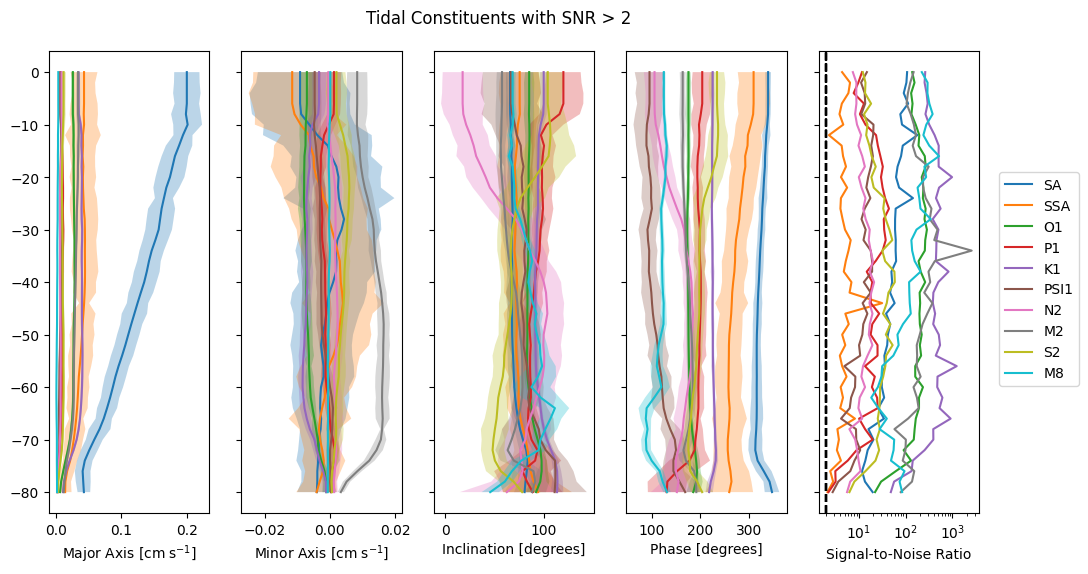

In [98]:
fig, axs = plt.subplots(1, 5, figsize=(12, 6), sharey=True)

for const in tide_out["constituent"].values:
    tide = tide_out.sel(constituent=const)
    if tide["snr"].min() < 2:
        continue
    fig, axs = plot_tidal_constituents(tide, const, fig)
handles, labels = axs[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="center", bbox_to_anchor=(0.95, 0.5))
fig.suptitle("Tidal Constituents with SNR > 2", fontsize=12, y=0.95)

In [112]:
constituents = widgets.SelectMultiple(
    options=tide_out.where(tide_out["snr"].min(dim="depth") > 2, drop=True)[
        "constituent"
    ].values,
    description="Constituents",
    disabled=False,
    rows=10,
)
display(constituents)

SelectMultiple(description='Constituents', options=(np.str_('SA'), np.str_('SSA'), np.str_('O1'), np.str_('P1'…

Text(0.5, 0.95, 'Selected Tidal Constituents')

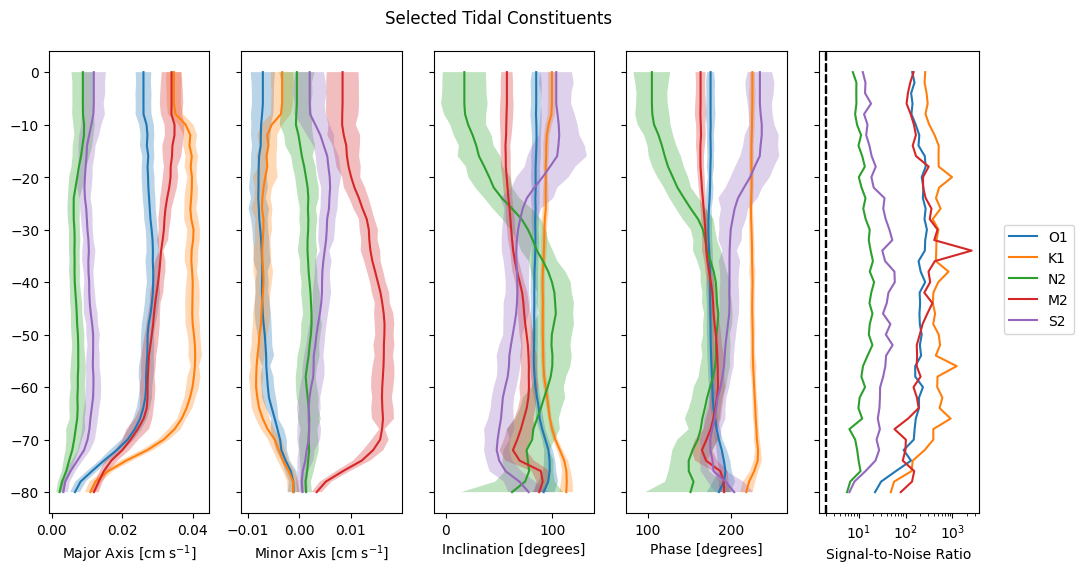

In [116]:
fig, axs = plt.subplots(1, 5, figsize=(12, 6), sharey=True)

for const in constituents.value:
    tide = tide_out.sel(constituent=const)
    fig, axs = plot_tidal_constituents(tide, const, fig)
handles, labels = axs[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="center", bbox_to_anchor=(0.95, 0.5))
fig.suptitle("Selected Tidal Constituents", fontsize=12, y=0.95)